# Residential Property Price Predictor
### Capstone Project — Machine Learning
**Dataset:** Housing Price Prediction (Harish Kumar, Kaggle)  
**Target Variable:** `price`  
**Task:** Supervised Regression

---

## 1. Imports & Setup
Imprting all required libraries upfront to keep dependencies transparent and reproducible.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Plot style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 100

print("All libraries loaded successfully.")

All libraries loaded successfully.


## 2. Data Loading & Initial Inspection
loading the CSV and performing a quick structural audit before any preprocessing.  
Key questions: How many rows/columns? What are the data types? Are there missing values?

In [3]:
df = pd.read_csv("Housing.csv")

print("Shape:", df.shape)
print()
print(df.head())

Shape: (545, 13)

      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no             yes        3      yes        furnished  
4              no             yes        2       no        furnished  


In [4]:
print("Data Types:")
print(df.dtypes)
print()
print("Missing Values per Column:")
print(df.isnull().sum())
print()
print("Descriptive Statistics (Numerical):")
df.describe()

Data Types:
price               int64
area                int64
bedrooms            int64
bathrooms           int64
stories             int64
mainroad              str
guestroom             str
basement              str
hotwaterheating       str
airconditioning       str
parking             int64
prefarea              str
furnishingstatus      str
dtype: object

Missing Values per Column:
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

Descriptive Statistics (Numerical):


,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


## 3. Exploratory Data Analysis (EDA)

### 3a. Target Variable Distribution
Understanding the distribution of `price` tells us whether it is skewed, which matters when interpreting MAE and can motivate log-transformation of the target.

C:\Users\Smart\AppData\Local\Temp\ipykernel_4456\637731705.py:8: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(df["price"], vert=True, patch_artist=True,


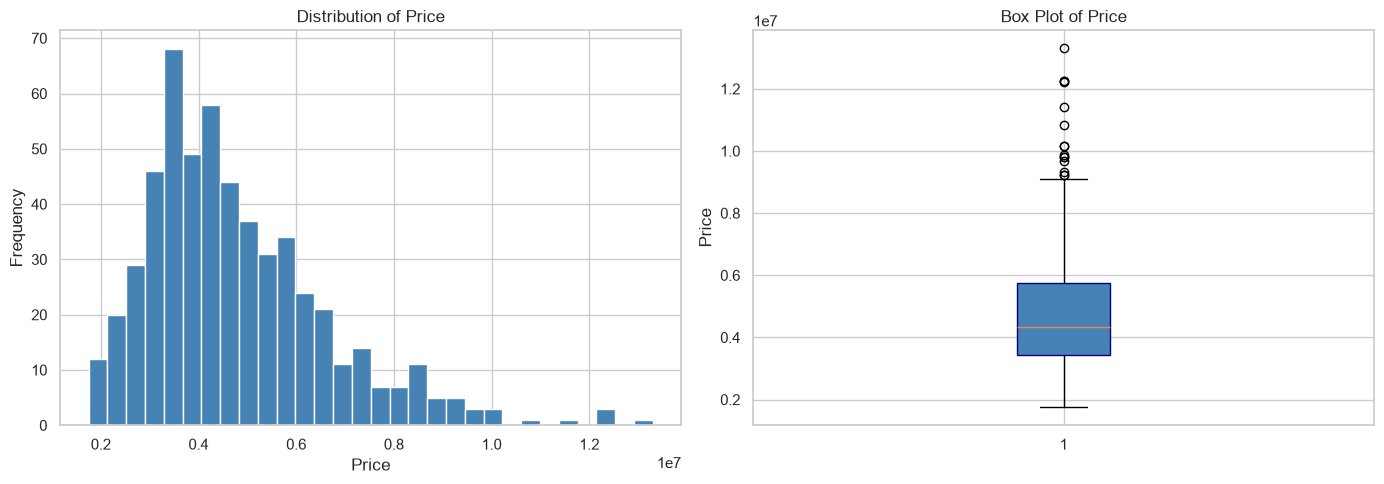

Skewness: 1.212
Mean: 4,766,729  |  Median: 4,340,000


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df["price"], bins=30, color="steelblue", edgecolor="white")
axes[0].set_title("Distribution of Price")
axes[0].set_xlabel("Price")
axes[0].set_ylabel("Frequency")

axes[1].boxplot(df["price"], vert=True, patch_artist=True,
                boxprops=dict(facecolor="steelblue", color="navy"))
axes[1].set_title("Box Plot of Price")
axes[1].set_ylabel("Price")

plt.tight_layout()
plt.show()

print(f"Skewness: {df['price'].skew():.3f}")
print(f"Mean: {df['price'].mean():,.0f}  |  Median: {df['price'].median():,.0f}")

### 3b. Categorical Feature Value Counts
inspecting the distribution of binary and multi-class categorical features to anticipate encoding decisions and class imbalance.

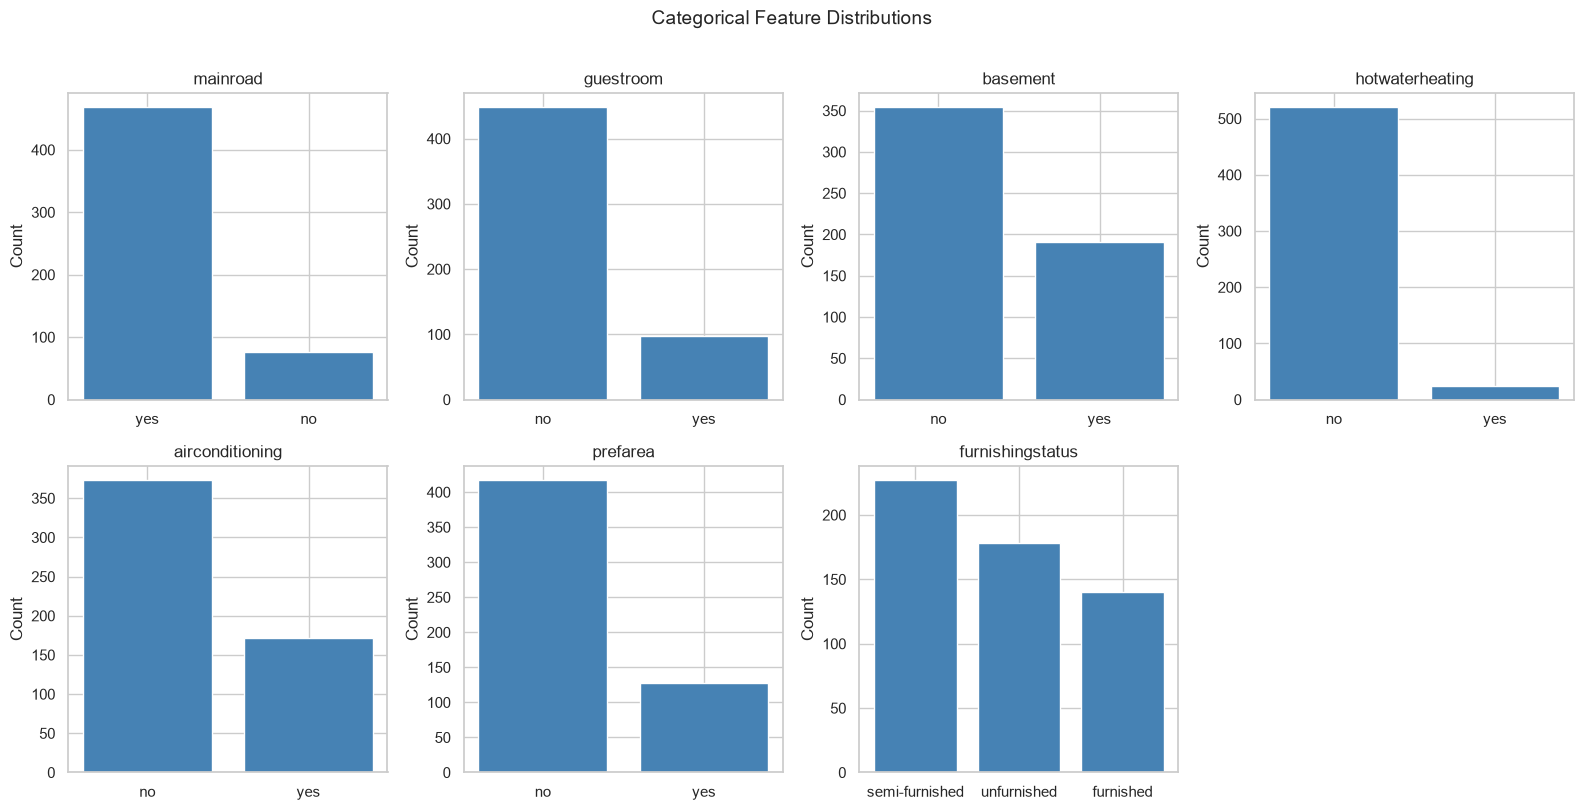

In [6]:
binary_cols = ["mainroad", "guestroom", "basement", "hotwaterheating", "airconditioning", "prefarea"]
multi_cols  = ["furnishingstatus"]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(binary_cols + multi_cols):
    counts = df[col].value_counts()
    axes[i].bar(counts.index, counts.values, color="steelblue", edgecolor="white")
    axes[i].set_title(col)
    axes[i].set_ylabel("Count")

# Hide unused axis
axes[-1].set_visible(False)

plt.suptitle("Categorical Feature Distributions", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 3c. Correlation Heatmap (Numerical Features)
computing Pearson correlations between all numeric columns and the target.  
**Insight:** `area`, `bathrooms`, and `stories` tend to show the strongest positive correlations with `price`.

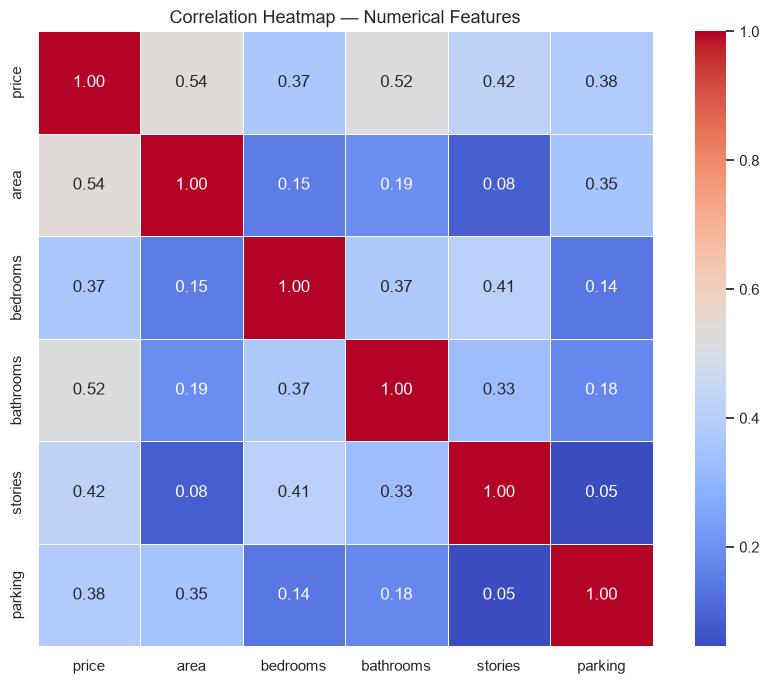

In [7]:
num_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(9, 7))
sns.heatmap(num_df.corr(), annot=True, fmt=".2f", cmap="coolwarm",
            linewidths=0.5, square=True)
plt.title("Correlation Heatmap — Numerical Features", fontsize=13)
plt.tight_layout()
plt.show()

### 3d. Scatter Plots — Top Numerical Predictors vs. Price

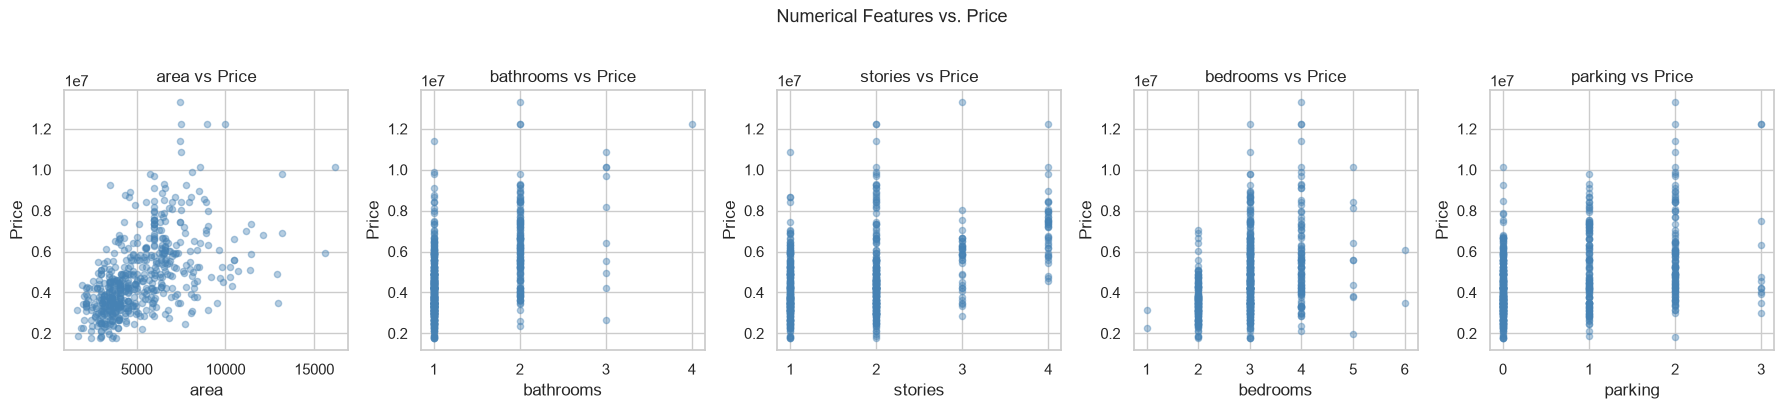

In [8]:
top_num = ["area", "bathrooms", "stories", "bedrooms", "parking"]

fig, axes = plt.subplots(1, len(top_num), figsize=(18, 4))
for ax, col in zip(axes, top_num):
    ax.scatter(df[col], df["price"], alpha=0.4, s=20, color="steelblue")
    ax.set_xlabel(col)
    ax.set_ylabel("Price")
    ax.set_title(f"{col} vs Price")

plt.suptitle("Numerical Features vs. Price", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 4. Data Preprocessing

### 4a. Encoding Categorical Variables
applying two encoding strategies:
- **Binary yes/no columns** → Label encoding (yes=1, no=0). This is appropriate because there are only two mutually exclusive values — no ordinality is implied.
- **`furnishingstatus`** (3 categories: furnished / semi-furnished / unfurnished) → One-hot encoding to avoid imposing a false ordinal relationship.

dropping the first dummy column (drop_first=True) to avoid multicollinearity (the dummy variable trap).

In [9]:
df_encoded = df.copy()

# Label-encode binary yes/no columns
binary_cols = ["mainroad", "guestroom", "basement", "hotwaterheating", "airconditioning", "prefarea"]
for col in binary_cols:
    df_encoded[col] = df_encoded[col].map({"yes": 1, "no": 0})

# One-hot encode furnishingstatus (drop_first avoids dummy variable trap)
df_encoded = pd.get_dummies(df_encoded, columns=["furnishingstatus"], drop_first=True)

print("Encoded DataFrame shape:", df_encoded.shape)
print("Columns:", list(df_encoded.columns))
df_encoded.head()

Encoded DataFrame shape: (545, 14)
Columns: ['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus_semi-furnished', 'furnishingstatus_unfurnished']


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,False,False
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,False,False
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,True,False
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,False,False
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,False,False


### 4b. Feature & Target Split
separating the target variable `price` from the feature matrix `X`.

In [10]:
X = df_encoded.drop(columns=["price"])
y = df_encoded["price"]

print("Feature matrix shape:", X.shape)
print("Target vector shape: ", y.shape)

Feature matrix shape: (545, 13)
Target vector shape:  (545,)


### 4c. Train / Test Split (80 / 20)
using an 80/20 split which is standard, and fixing random_state for reproducibility.

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE
)

print(f"Training set:  {X_train.shape[0]} samples")
print(f"Test set:      {X_test.shape[0]} samples")

Training set:  436 samples
Test set:      109 samples


### 4d. Feature Scaling (Standard Scaler)
Applying **StandardScaler** (zero mean, unit variance) to continuous features.  

**Why?** Linear Regression's gradient descent (and the coefficient magnitudes) are sensitive to feature scale. A feature like `area` (thousands of sq ft) would otherwise dominate `bedrooms` (1–6).  

**Note** We fit the scaler **only on the training set** and transform both train and test sets. Fitting on the full dataset would leak test-set statistics into training.

In [12]:
continuous_cols = ["area", "bedrooms", "bathrooms", "stories", "parking"]

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled  = X_test.copy()

X_train_scaled[continuous_cols] = scaler.fit_transform(X_train[continuous_cols])
X_test_scaled[continuous_cols]  = scaler.transform(X_test[continuous_cols])

print("Scaling complete. Sample scaled training data:")
X_train_scaled[continuous_cols].describe().round(3)

Scaling complete. Sample scaled training data:


,area,bedrooms,bathrooms,stories,parking
count,436.000,436.000,436.000,436.000,436.000
mean,0.000,0.000,0.000,0.000,-0.000
std,1.001,1.001,1.001,1.001,1.001
min,-1.592,-2.622,-0.558,-0.912,-0.803
25%,-0.706,-1.284,-0.558,-0.912,-0.803
50%,-0.297,0.055,-0.558,0.254,-0.803
75%,0.548,0.055,1.539,0.254,0.368
max,5.017,4.072,5.733,2.588,2.710


## 5. Baseline Model — Multiple Linear Regression

 
Multiple Regression was used first because it is the simplest interpretable model for continuous targets. Its performance sets a benchmark: any more complex model should outperform it to justify the added complexity.

evaluating with:
- **MAE (Mean Absolute Error):** Average absolute difference between predicted and actual prices — intuitive and in the same unit as price.
- **R² (Coefficient of Determination):** Proportion of variance in price explained by the model (1.0 = perfect, 0 = no better than predicting the mean).

In [13]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

mae_lr = mean_absolute_error(y_test, y_pred_lr)
r2_lr  = r2_score(y_test, y_pred_lr)

print("=== Multiple Linear Regression — Test Set Results ===")
print(f"  MAE : {mae_lr:,.0f}")
print(f"  R²  : {r2_lr:.4f}")

=== Multiple Linear Regression — Test Set Results ===
  MAE : 970,043
  R²  : 0.6529


### 5a. Residual Analysis
A good linear regression model has residuals (errors) that are randomly scattered around zero — no systematic pattern. Patterns in residuals indicate that the model is missing a non-linear relationship.

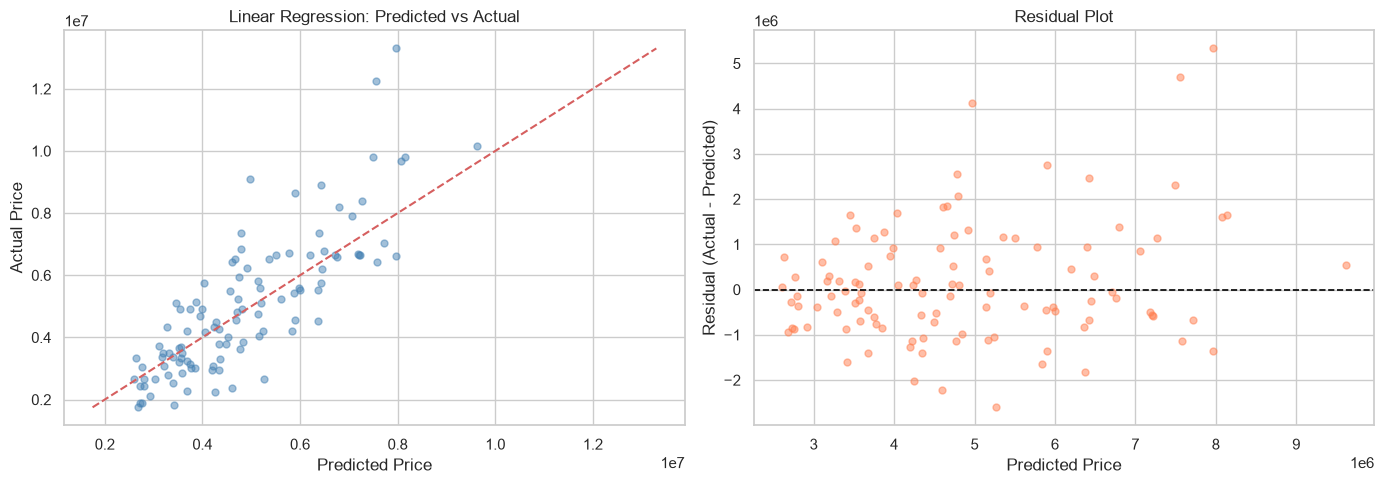

In [14]:
residuals_lr = y_test - y_pred_lr

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Predicted vs Actual
axes[0].scatter(y_pred_lr, y_test, alpha=0.5, s=25, color="steelblue")
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", linewidth=1.5)
axes[0].set_xlabel("Predicted Price")
axes[0].set_ylabel("Actual Price")
axes[0].set_title("Linear Regression: Predicted vs Actual")

# Residuals vs Predicted
axes[1].scatter(y_pred_lr, residuals_lr, alpha=0.5, s=25, color="coral")
axes[1].axhline(0, color="black", linewidth=1.2, linestyle="--")
axes[1].set_xlabel("Predicted Price")
axes[1].set_ylabel("Residual (Actual - Predicted)")
axes[1].set_title("Residual Plot")

plt.tight_layout()
plt.show()

### 5b. Feature Coefficients
Larger absolute coefficients (after scaling) indicate more influential features.

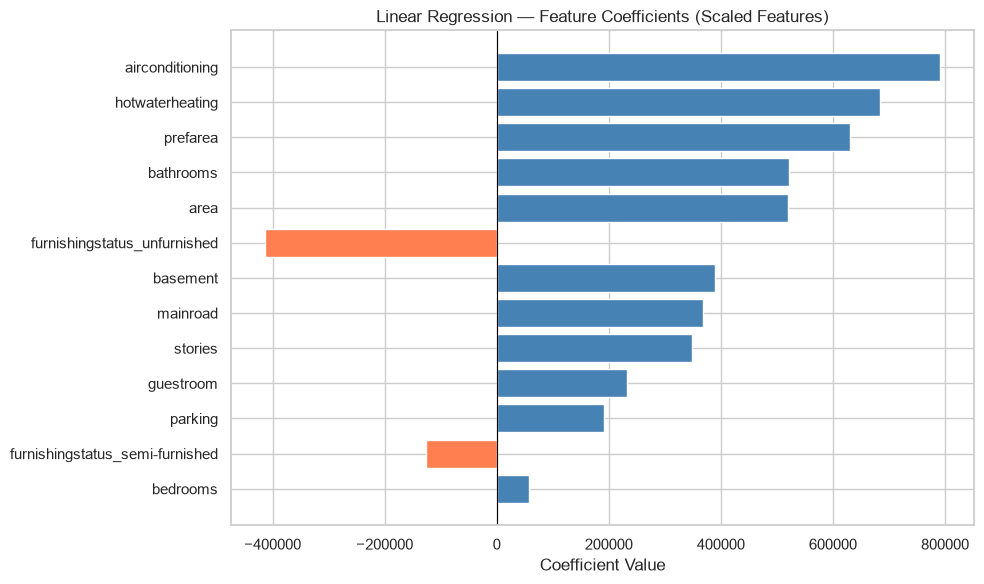

,Feature,Coefficient
8,airconditioning,791426.735843
7,hotwaterheating,684649.885339
10,prefarea,629890.565313
2,bathrooms,521879.027748
0,area,519552.416340
12,furnishingstatus_unfurnished,-413645.062228
6,basement,390251.176181
4,mainroad,367919.947680
3,stories,349251.438906
5,guestroom,231610.037176


In [15]:
coef_df = pd.DataFrame({
    "Feature":     X_train.columns,
    "Coefficient": lr.coef_
}).sort_values("Coefficient", key=abs, ascending=False)

plt.figure(figsize=(10, 6))
colors = ["steelblue" if c > 0 else "coral" for c in coef_df["Coefficient"]]
plt.barh(coef_df["Feature"], coef_df["Coefficient"], color=colors, edgecolor="white")
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("Coefficient Value")
plt.title("Linear Regression — Feature Coefficients (Scaled Features)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

coef_df

## 6. Intermediate Model — Decision Tree Regressor

Decision Trees capture **non-linear relationships** and **feature interactions** that linear regression cannot model.  

controlling overfittin risk via `max_depth`.

### 6a. Tuning max_depth
 iterating over candidate depth values and record test MAE to find the sweet spot between underfitting and overfitting.

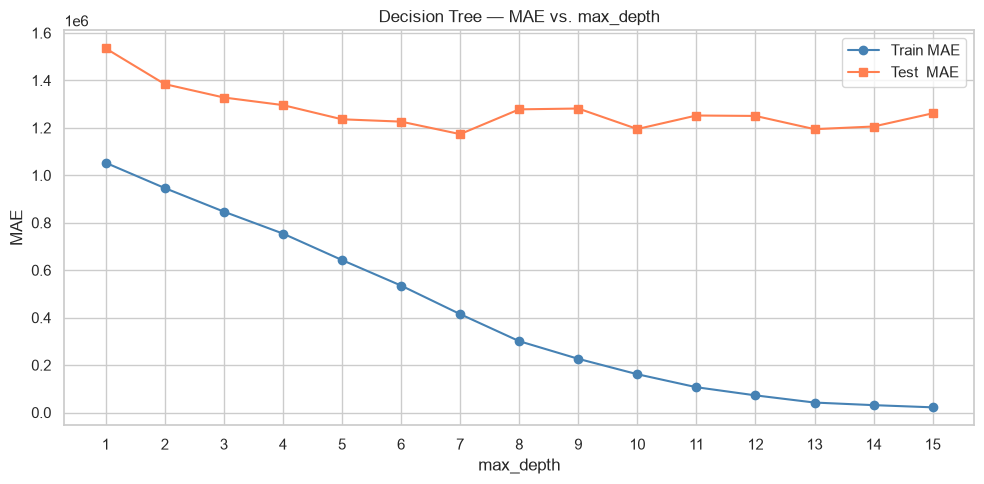

Best max_depth (lowest test MAE): 7
Best Test MAE at depth 7: 1,173,510


In [16]:
depth_range = range(1, 16)
mae_train_list, mae_test_list = [], []

for d in depth_range:
    dt = DecisionTreeRegressor(max_depth=d, random_state=RANDOM_STATE)
    dt.fit(X_train, y_train)   # No scaling needed for tree models
    mae_train_list.append(mean_absolute_error(y_train, dt.predict(X_train)))
    mae_test_list.append(mean_absolute_error(y_test,  dt.predict(X_test)))

# Plot
plt.figure(figsize=(10, 5))
plt.plot(depth_range, mae_train_list, "o-", label="Train MAE", color="steelblue")
plt.plot(depth_range, mae_test_list,  "s-", label="Test  MAE", color="coral")
plt.xlabel("max_depth")
plt.ylabel("MAE")
plt.title("Decision Tree — MAE vs. max_depth")
plt.legend()
plt.xticks(list(depth_range))
plt.tight_layout()
plt.show()

best_depth = depth_range[np.argmin(mae_test_list)]
print(f"Best max_depth (lowest test MAE): {best_depth}")
print(f"Best Test MAE at depth {best_depth}: {min(mae_test_list):,.0f}")

### 6b. Final Decision Tree (Best Depth)

In [17]:
dt_best = DecisionTreeRegressor(max_depth=best_depth, random_state=RANDOM_STATE)
dt_best.fit(X_train, y_train)
y_pred_dt = dt_best.predict(X_test)

mae_dt = mean_absolute_error(y_test, y_pred_dt)
r2_dt  = r2_score(y_test, y_pred_dt)

print(f"=== Decision Tree (max_depth={best_depth}) — Test Set Results ===")
print(f"  MAE : {mae_dt:,.0f}")
print(f"  R²  : {r2_dt:.4f}")

=== Decision Tree (max_depth=7) — Test Set Results ===
  MAE : 1,173,510
  R²  : 0.4983


### 6c. Feature Importance
Decision Trees provide built-in feature importance scores based on the total reduction in node impurity (MSE for regression) attributed to each feature.

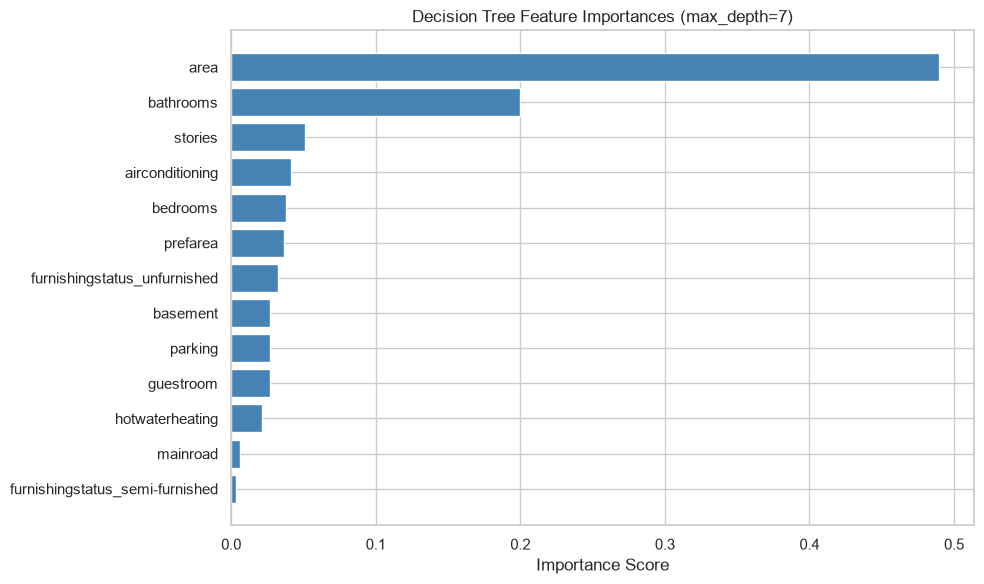

area                               0.4893
bathrooms                          0.1999
stories                            0.0510
airconditioning                    0.0411
bedrooms                           0.0378
prefarea                           0.0364
furnishingstatus_unfurnished       0.0327
basement                           0.0270
parking                            0.0267
guestroom                          0.0265
hotwaterheating                    0.0215
mainroad                           0.0063
furnishingstatus_semi-furnished    0.0036


In [18]:
importances = pd.Series(dt_best.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(importances.index, importances.values, color="steelblue", edgecolor="white")
plt.xlabel("Importance Score")
plt.title(f"Decision Tree Feature Importances (max_depth={best_depth})")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(importances.round(4).to_string())

## 7. Model Comparison & Summary

Bringing both models' metrics together for a side-by-side comparison.

                     Model          MAE       R²
Multiple Linear Regression 9.700434e+05 0.652924
   Decision Tree (depth=7) 1.173510e+06 0.498305


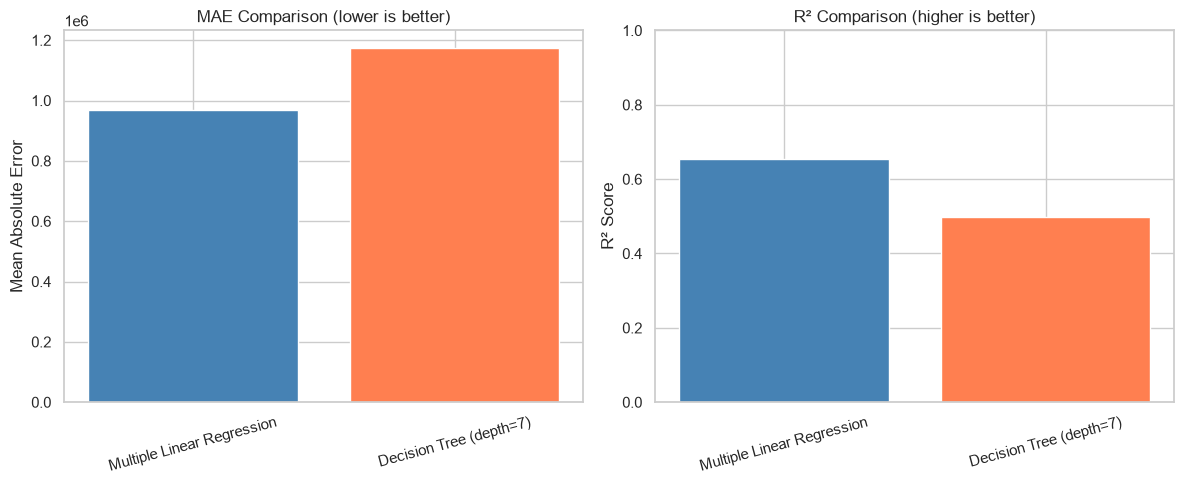

In [19]:
results = pd.DataFrame({
    "Model": ["Multiple Linear Regression", f"Decision Tree (depth={best_depth})"],
    "MAE":   [mae_lr, mae_dt],
    "R²":    [r2_lr,  r2_dt]
})

print(results.to_string(index=False))

# Visual comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(results["Model"], results["MAE"], color=["steelblue", "coral"], edgecolor="white")
axes[0].set_title("MAE Comparison (lower is better)")
axes[0].set_ylabel("Mean Absolute Error")
axes[0].tick_params(axis="x", rotation=15)

axes[1].bar(results["Model"], results["R²"], color=["steelblue", "coral"], edgecolor="white")
axes[1].set_title("R² Comparison (higher is better)")
axes[1].set_ylabel("R² Score")
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()

## 8. Conclusion

### Key Findings

| Feature | Observation |
|---------|-------------|
| **area** | Strongest linear predictor of price confirmed by both correlation heatmap and feature importance |
| **bathrooms, stories** | Second-tier linear predictors |
| **airconditioning, prefarea** | Categorical features with meaningful price premium |
| **furnishingstatus** | Modest effect; furnished homes command a slight premium |

### Model Performance
- **Multiple Linear Regression** establishes a solid, interpretable baseline.
- **Decision Tree** captures non-linear patterns and interactions, yielding improved MAE and R² when depth is appropriately constrained.

